# Training

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import d3rlpy
import ast
from d3rlpy.metrics import TDErrorEvaluator, InitialStateValueEstimationEvaluator
import torch

from google import genai
from google.genai import types
from dotenv import load_dotenv
from typing import Literal
import random
from pydantic import BaseModel, Field

import os


load_dotenv()
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
client = genai.Client(api_key=GOOGLE_API_KEY)

print(f"Cuda available: {torch.cuda.is_available()}")

# Load data, Encode Action
df = pd.read_csv("transition_df.csv")

decode_map = {
    1: 'A_Persuade',
    2: 'A_Incentive',
    3: 'B_Persuade',
    4: 'B_Incentive',
    5: 'C_Persuade',
    6: 'C_Incentive',
    7: 'Closing'
}

action_counts = df['action'].map(decode_map).value_counts()
print(f"Action frequencies:\n {action_counts}")
print(f"Total transitions: {len(df)}")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Cuda available: True
Action frequencies:
 action
C_Persuade     209
A_Persuade     192
B_Persuade     164
C_Incentive    110
B_Incentive    106
A_Incentive     92
Closing         19
Name: count, dtype: int64
Total transitions: 892


In [8]:
df.head()

,convo_id,round,chat_history_0,chat_history_1,action,end_convo,final_state
0,0,3,"The customer, initially direct and slightly sk...",The chat begins with the agent greeting the cu...,6,False,NaN
1,0,4,The chat begins with the agent greeting the cu...,The customer initiated the chat seeking genuin...,2,False,NaN
2,0,5,The customer initiated the chat seeking genuin...,Customer buys,4,True,Customer buys
3,1,3,The customer began with a somewhat demanding a...,Customer leaves call,1,True,Customer leaves call
4,2,3,The agent greeted the customer and offered ass...,"The customer, initially seeking durable and wa...",5,False,NaN


In [4]:
def embedding_gemini(text_list: list[str]) -> np.ndarray:
    client = genai.Client()
    all_embeddings = []
    
    # Break into chunks of 80 to stay safely under the 100-limit
    for i in range(0, len(text_list), 80):
        chunk = text_list[i : i + 80]
        
        result = client.models.embed_content(
            model="gemini-embedding-001",
            contents=chunk,
            config=types.EmbedContentConfig(
                task_type="CLASSIFICATION", 
                output_dimensionality=512
            )
        )
        
        # Extract values for this chunk
        chunk_embeddings = np.array([e.values for e in result.embeddings])
        all_embeddings.append(chunk_embeddings)

    # Combine all chunks into one matrix
    embeddings = np.vstack(all_embeddings)
    
    # Normalize the final matrix
    norms = np.linalg.norm(embeddings, axis=-1, keepdims=True)
    return embeddings / norms

In [5]:
from sklearn.decomposition import PCA

states = embedding_gemini(df['chat_history_0'].tolist())
next_states = embedding_gemini(df['chat_history_1'].tolist())
print("Embedding complete.")

Embedding complete.


In [38]:
pca = PCA(n_components=0.95, svd_solver='full')
states_pca = pca.fit_transform(states)
next_states_pca = pca.transform(next_states)

print(f"PCA reduced states shape: {states_pca.shape} (kept {pca.n_components_} components)")

states = states_pca
next_states = next_states_pca

PCA reduced states shape: (892, 174) (kept 174 components)


In [39]:
def compute_reward(row):
    if row['chat_history_1'] == 'Customer buys':
        if row['action'] == 2:
            return 42
        elif row['action'] == 4:
            return 27
        elif row['action'] == 6:
            return 37
    if row['chat_history_1'] == 'Customer leaves call':
        return -13
    return -3

df['reward'] = df.apply(compute_reward, axis=1)

In [40]:
actions = df['action'].values.astype(np.int32)
rewards = df['reward'].values.astype(np.float32)
terminals = df['end_convo'].values.astype(np.float32)

dataset = d3rlpy.dataset.MDPDataset(
    observations=states,
    actions=actions,
    rewards=rewards,
    terminals=terminals
)

print(f"Dataset created with {len(dataset.episodes)} episodes and {len(states)} transitions.")

2026-01-29 16:43.15 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int32')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float64')], shape=[(174,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2026-01-29 16:43.15 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2026-01-29 16:43.15 [info     ] Action size has been automatically determined. action_size=8
Dataset created with 404 episodes and 892 transitions.


In [41]:
encoder = d3rlpy.models.VectorEncoderFactory(hidden_units=[32, 16])
dqn_config = d3rlpy.algos.DQNConfig(
    learning_rate=3e-5,
    batch_size=64,
    observation_scaler=d3rlpy.preprocessing.StandardObservationScaler(),
    encoder_factory=encoder
)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"DQN is using device: {device}")
dqn = dqn_config.create(device=device)
dqn.build_with_dataset(dataset)

dqn.fit(dataset, n_steps= 2000, n_steps_per_epoch=20, show_progress=True)
dqn.save_model("sales_dqn_model.d3")

DQN is using device: cuda:0
2026-01-29 16:43.21 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float64')], shape=[(174,)]), action_signature=Signature(dtype=[dtype('int32')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=8)
2026-01-29 16:43.21 [debug    ] Fitting observation scaler...  observation_scaler=standard
2026-01-29 16:43.21 [warning  ] Skip building models since they're already built.
2026-01-29 16:43.21 [info     ] Directory is created at d3rlpy_logs\DQN_20260129164321
2026-01-29 16:43.21 [info     ] Parameters                     params={'observation_shape': [174], 'action_size': 8, 'config': {'type': 'dqn', 'params': {'batch_size': 64, 'gamma': 0.99, 'observation_scaler': {'type': 'standard', 'params': {'mean': [-1.4157832853263627e-17, 3.587688193365486e-17, -2.8315665706527256e-18, 5.460878386258828e-18, 7.902521126268

Epoch 1/100: 100%|██████████| 20/20 [00:00<00:00, 120.15it/s, loss=9.84]


2026-01-29 16:43.21 [info     ] DQN_20260129164321: epoch=1 step=20 epoch=1 metrics={'time_sample_batch': 0.0014999747276306153, 'time_algorithm_update': 0.00657883882522583, 'loss': 9.844823145866394, 'time_step': 0.00818009376525879} step=20
2026-01-29 16:43.21 [info     ] Model parameters are saved to d3rlpy_logs\DQN_20260129164321\model_20.d3


Epoch 2/100: 100%|██████████| 20/20 [00:00<00:00, 135.78it/s, loss=9.97]


2026-01-29 16:43.21 [info     ] DQN_20260129164321: epoch=2 step=40 epoch=2 metrics={'time_sample_batch': 0.0010171175003051759, 'time_algorithm_update': 0.006197726726531983, 'loss': 9.72517957687378, 'time_step': 0.007314956188201905} step=40
2026-01-29 16:43.21 [info     ] Model parameters are saved to d3rlpy_logs\DQN_20260129164321\model_40.d3


...

2026-01-29 16:43.42 [info     ] DQN_20260129164321: epoch=98 step=1960 epoch=98 metrics={'time_sample_batch': 0.001911795139312744, 'time_algorithm_update': 0.0070485234260559086, 'loss': 9.420139455795288, 'time_step': 0.00906059741973877} step=1960
2026-01-29 16:43.42 [info     ] Model parameters are saved to d3rlpy_logs\DQN_20260129164321\model_1960.d3


Epoch 99/100: 100%|██████████| 20/20 [00:00<00:00, 120.13it/s, loss=9.39]


2026-01-29 16:43.42 [info     ] DQN_20260129164321: epoch=99 step=1980 epoch=99 metrics={'time_sample_batch': 0.001070559024810791, 'time_algorithm_update': 0.0071011543273925785, 'loss': 9.291040277481079, 'time_step': 0.00825115442276001} step=1980
2026-01-29 16:43.42 [info     ] Model parameters are saved to d3rlpy_logs\DQN_20260129164321\model_1980.d3


Epoch 100/100: 100%|██████████| 20/20 [00:00<00:00, 99.00it/s, loss=10]  


2026-01-29 16:43.42 [info     ] DQN_20260129164321: epoch=100 step=2000 epoch=100 metrics={'time_sample_batch': 0.0015966057777404784, 'time_algorithm_update': 0.008166015148162842, 'loss': 9.810300803184509, 'time_step': 0.009961342811584473} step=2000
2026-01-29 16:43.42 [info     ] Model parameters are saved to d3rlpy_logs\DQN_20260129164321\model_2000.d3


# Loss Function Plot

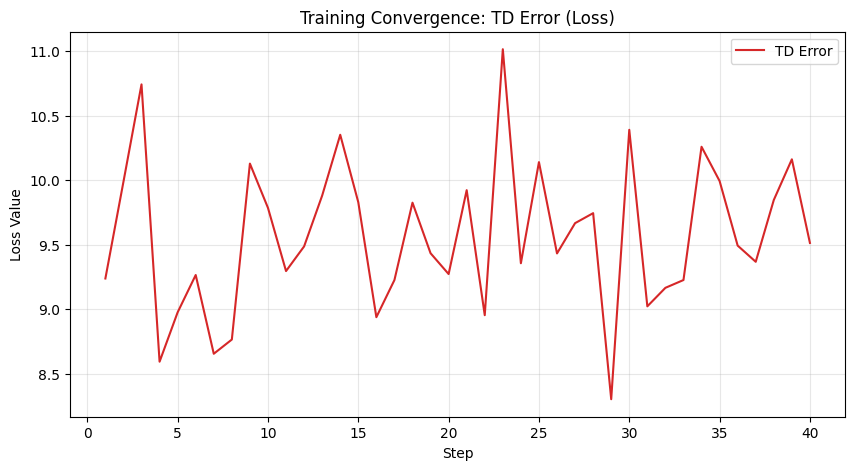

Final recorded loss: 9.512972


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Point to your log folder
log_folder = r"d3rlpy_logs\DQN_20260129163834"
loss_path = os.path.join(log_folder, "loss.csv")

# 2. Load and Plot
if os.path.exists(loss_path):
    # Headerless CSVs in d3rlpy often use column 1 for the step and column 2 for the value
    loss_df = pd.read_csv(loss_path, header=None, names=['epoch', 'step', 'loss'])
    
    plt.figure(figsize=(10, 5))
    plt.plot(loss_df['epoch'], loss_df['loss'], color='tab:red', label='TD Error')
    
    plt.title('Training Convergence: TD Error (Loss)')
    plt.xlabel('Step')
    plt.ylabel('Loss Value')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # Quick Check: Print the final loss value
    print(f"Final recorded loss: {loss_df['loss'].iloc[-1]:.6f}")
else:
    print(f"Error: Could not find loss.csv at {loss_path}")

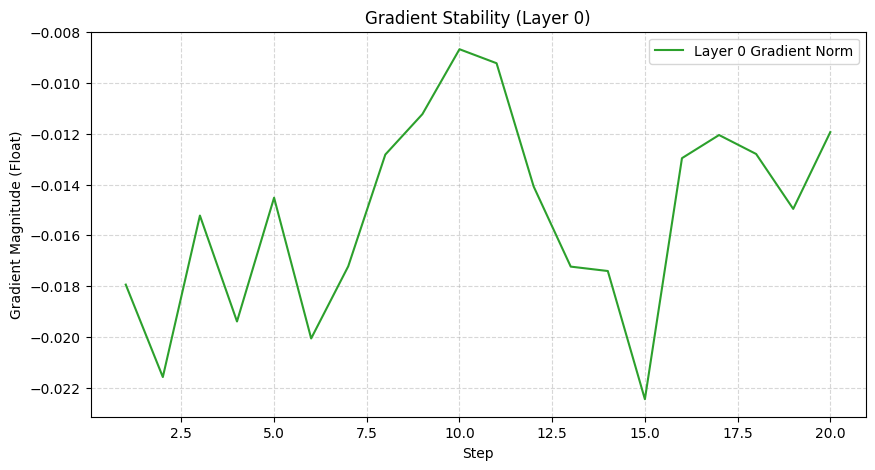

In [28]:
import os

grad_path = log_folder + r"\q_funcs.0._encoder._layers.0.weight_grad.csv"

if os.path.exists(grad_path):
    # Load with no header and force columns to be floats
    # Column 0: Step/Epoch, Column 1: Placeholder, Column 2: Gradient Norm
    grad_df = pd.read_csv(grad_path, header=None)
    
    # Force conversion to numeric, turning errors into NaN just in case
    steps = pd.to_numeric(grad_df[0], errors='coerce')
    grad_values = pd.to_numeric(grad_df[2], errors='coerce')

    plt.figure(figsize=(10, 5))
    plt.plot(steps, grad_values, label='Layer 0 Gradient Norm', color='tab:green')
    
    plt.title('Gradient Stability (Layer 0)')
    plt.ylabel('Gradient Magnitude (Float)')
    plt.xlabel('Step')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Inference

In [ ]:
Round_limit = 15
customer_exit_round = 6

sell_price = 100
base_cost = 50
single_labor_cost = 3
customer_end_call_penalty = 10
A_incentive_cost = 5
B_incentive_cost = 20
C_incentive_cost = 10

agent_sys_prompt = f"""
You are an expert sales agent selling leather boots. Your task is to generate a natural language response to the customer's message, based on the action provided.

### ACTIONS
- Greeting: This only happens at the first round.
- Recommendation: This only happens at the second round.
- When customer raises Objection, an action Incentive/Persuade/Closing will be selected.
- A_Incentive: provide extended warranty.
- B_Incentive: provide discounted price at {100 - B_incentive_cost}.
- C_Incentive: provide free shipping.
- A_Persuade, B_Persuade, C_Persuade: Logical counter-arguments.
- Closing: End the call immediately to cut labor cost and avoid customer end call penalty.

### RULES
Your response must alighn with the action provided. You MUST NOT change the action.
"""

def generate_chat_history_summary(chat_history: str) -> str:
    """
    Generate a summary of the chat history.
    """

    system_prompt = '''
    You are an expert customer service representative.
    Your task is to summarize the chat history into a short paragraph, with a focus on customer's tone, sentiment, and all speaker's action.
    '''

    config = genai.types.GenerateContentConfig(
        system_instruction = system_prompt,
        response_mime_type="text/plain",
        temperature=0.0,
    )

    response = client.models.generate_content(
        model = "gemini-2.5-flash",
        contents = chat_history,
        config = config,
    )

    return response.text

In [3]:
import random
from utils import generate_customer_profile, select_next_objection, set_objection_indicator, raise_new_objection, react_to_handling, generate_customer_sys_prompt

dqn = dqn_config.create(device=device)
dqn.load_model("sales_dqn_model.d3")

def inference_DQN(customer_model="gemini-2.5-flash", agent_model="gemini-2.5-flash"):
    profile = generate_customer_profile() # Returns {'patience': float, 'determination': float}
    patience = profile["patience"]
    determination = profile["determination"]
    
    # Environment Hidden State
    A_priority, B_priority, C_priority = random.random(), random.random(), random.random()
    
    factors = {k: random.uniform(0.7, 0.9) for k in ['A', 'B', 'C']}
    factors['C'] = factors['A'] * factors['C']
    factors['B'] = factors['C'] * factors['B']
    
    concern_used = {'A': False, 'B': False, 'C': False}
    incentive_cost_total = 0
    current_round = 0
    active_objection = None
    logic_result = None
    final_state = "In Progress"
    
    history_data = []

    # Initialize Chats
    agent_chat = client.chats.create(
        model=agent_model,
        config=types.GenerateContentConfig(
            system_instruction=agent_sys_prompt
        )
    )
    customer_chat = client.chats.create(
        model=customer_model,
        config=types.GenerateContentConfig(
            system_instruction=generate_customer_sys_prompt(patience, determination)
        )
    )

    # --- SIMULATION LOOP ---
    # Round 1: Agent Greeting -> Customer Reply
    current_round = 1
    agent_text = agent_chat.send_message("Start the call: Greet the customer professionally. Current round: {current_round}.").text
    history_data.append({"speaker": "Agent", "round": current_round, "text": agent_text, "action": "Greeting"})
    
    customer_text = customer_chat.send_message(f"Agent said: {agent_raw.text}. Responds to the greeting, ask for recommendation.")
    history_data.append({"speaker": "Customer", "round": current_round, "text": customer_text, "action": "Greeting_Response"})
    
    # Round 2: Agent Recommendation (No customer reply yet, they reply in the loop)
    current_round = 2
    agent_text = agent_chat.send_message(f"Current round: {current_round}, Customer said: {customer_text}. Make a recommendation.").text
    history_data.append({"speaker": "Agent", "round": current_round, "text": agent_text, "action": "Recommendation"})
    last_agent_msg = agent_text

    while current_round < Round_limit:
        current_round += 1
        
        # --- PHASE 1: CUSTOMER SIDE ---
        # Check for random exit based on Patience
        if current_round >= customer_exit_round and random.random() > patience:
            final_state = "Customer leaves call"
            break
        
        if not active_objection:
            active_objection = select_next_objection(A_priority, B_priority, C_priority, concern_used)
            if not active_objection:
                # Final Buy check if no more concerns exist
                if random.random() > determination:
                    final_state = "Customer buys"
                else:
                    final_state = "No Buy"
                break
            
            customer_action = active_objection
            set_objection_indicator(active_objection, concern_used)
            customer_text = raise_new_objection(customer_chat, active_objection, last_agent_msg)
        else:
            customer_action = f"{active_objection}"
            customer_text = react_to_handling(customer_chat, logic_result, last_agent_msg)

        history_data.append({"speaker": "Customer", "round": current_round, "text": customer_text, "action": customer_action})

        # --- PHASE 2: AGENT SIDE (INFERENCE) ---
        rows = []
        for _, row in history_data.iterrows():
            rows.append(f"{row['speaker']} [{row['action']}] : {row['text']}")
        for _, row in history_data.iterrows():
            rows.append(f"{row['speaker']} [{row['action']}] : {row['text']}")
        chat_history = "\n".join(rows)

        # embedding = chat_history -> summary -> embedding
        chat_history_summary = generate_chat_history_summary(chat_history)
        # state = np.concatenate([embedding.flatten(), np.array([current_round]).flatten()]).reshape(1, -1)

        # Select agent_action according to customer_action constraints
        # agent_action should be integer from 1 to 7, pick highest Q-value among allowed for each objection

        # 1. Use a dictionary for cleaner mapping and to avoid typo bugs
        action_map = {
            'Objection_A': [1, 2, 7],
            'Objection_B': [3, 4, 7],
            'Objection_C': [5, 6, 7]
        }

        # 2. Determine allowed actions
        # .get() handles the 'else' case automatically if key isn't found
        allowed_actions = action_map.get(customer_action, list(range(1, 8)))

        # 3. Get Q-values for the current state
        # Note: Most DQN models return values for ALL actions at once
        q_values = dqn.predict_value([state])[0] 

        # 4. Mask the disallowed actions
        # We set disallowed actions to a very low number so they aren't picked
        masked_q = np.full_like(q_values, -np.inf)
        for a in allowed_actions:
            # Subtract 1 if your actions are 1-indexed but your array is 0-indexed
            masked_q[a-1] = q_values[a-1]

        # 5. Pick the best action index
        best_action_idx = np.argmax(masked_q) + 1 

        # 6. Decode the action (using the dict properly)
        agent_action = decode_map[best_action_idx]

        agent_text = agent_chat.send_message(f"Current Round: {current_round}, Agent Action:{agent_action}. Customer said: {customer_text}").text

        last_agent_msg = agent_text
        last_agent_action = agent_action
        
        history_data.append({"speaker": "Agent", "round": current_round, "text": agent_text, "action": agent_action})

        # --- PHASE 3: EVALUATE PHYSICS (Transition Rules) ---
        if "Persuade" in last_agent_action:
            if random.random() > determination:
                logic_result = "Resolved"
                active_objection = None
                if random.random() < 1/3:
                    final_state = "Customer buys"
                    break
            elif random.random() < 1/3:
                final_state = "Customer leaves call"
                break
            else:       
                logic_result = "Still Skeptical"    
        
        elif "Incentive" in last_agent_action:
            cat = last_agent_action.split("_")[0] 
            active_objection = None
            if random.random() > (factors[cat] * determination):
                final_state = "Customer buys"
                if cat == "A": incentive_cost_total = 5
                elif cat == "B": incentive_cost_total = 30
                elif cat == "C": incentive_cost_total = 10
                break
            else:
                logic_result = "Incentive Rejected"
        
        elif last_agent_action == "Closing":
            final_state = "Agent Closed"
            break

    # --- 5. TERMINAL CALCULATION ---
    labor_cost = current_round * single_labor_cost
    if final_state == "Customer buys":
        final_profit = (sell_price - base_cost) - incentive_cost_total - labor_cost
    elif final_state == "Customer leaves call":
        final_profit = -customer_end_call_penalty - labor_cost
    else:
        final_profit = -labor_cost

    # Add 'end_convo' field to each history_data row: True only for last round 'Agent', else False
    max_agent_round = max([row["round"] for row in history_data if row["speaker"] == "Agent"])
    for row in history_data:
        if row["speaker"] == "Agent" and row["round"] == max_agent_round:
            row["end_convo"] = True
        else:
            row["end_convo"] = False

    return pd.DataFrame(history_data), final_state, final_profit

NameError: name 'dqn_config' is not defined